# Прогноз объёма погрузки по станциям

**План:**
1. Загрузка и предобработка данных
2. Поиск аномалий в данных
3. EDA
4. Вспомогательные функции
5. Обоснование выбора моделей
6. Walk-forward валидация (2 фолда)
7. Сравнение метрик качества
8. Профили станций
9. Прогноз на январь–июнь 2024
10. Экспорт прогноза в Excel
11. Выводы

In [110]:
#загрузка библиотек
import warnings
warnings.filterwarnings('ignore')

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.base import clone

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

## 1. Загрузка и предобработка данных

In [111]:
raw = pd.read_excel('/content/Прогноз погрузки.xlsx')
raw.info()
raw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Станция погрузки  864 non-null    object        
 1   Объем             827 non-null    float64       
 2   Период            864 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 20.4+ KB


,Станция погрузки,Объем,Период
0,Станция погрузки 1,2719.0,2021-01-01
1,Станция погрузки 2,662.0,2021-01-01
2,Станция погрузки 3,137.0,2021-01-01
3,Станция погрузки 4,5926.0,2021-01-01
4,Станция погрузки 5,312.0,2021-01-01


In [112]:
STATION_COL, VOLUME_COL, DATE_COL = raw.columns
raw[DATE_COL] = pd.to_datetime(raw[DATE_COL])
raw = raw.sort_values([STATION_COL, DATE_COL]).reset_index(drop=True)

In [113]:
pivot_raw = raw.pivot_table(index=DATE_COL, columns=STATION_COL, values=VOLUME_COL).sort_index()
stations = list(pivot_raw.columns)
short_names = [s.replace('Станция погрузки ', 'Ст ') for s in stations]

In [114]:
pivot = pivot_raw.copy()
for st in stations:
    pivot[st] = pivot[st].interpolate(method='linear').ffill().bfill()

In [115]:
print(f'Диапазон дат: {raw[DATE_COL].min().date()} — {raw[DATE_COL].max().date()}')
print(f'Станций: {len(stations)}, месяцев: {len(pivot)}')
print(f'Пропусков до интерполяции: {pivot_raw.isna().sum().sum()} из {pivot_raw.size}')

Диапазон дат: 2021-01-01 — 2023-12-01
Станций: 24, месяцев: 36
Пропусков до интерполяции: 37 из 864


In [116]:
pivot.head()

Станция погрузки,Станция погрузки 1,Станция погрузки 10,Станция погрузки 11,Станция погрузки 12,Станция погрузки 13,Станция погрузки 14,Станция погрузки 15,Станция погрузки 16,Станция погрузки 17,Станция погрузки 18,...,Станция погрузки 22,Станция погрузки 23,Станция погрузки 24,Станция погрузки 3,Станция погрузки 4,Станция погрузки 5,Станция погрузки 6,Станция погрузки 7,Станция погрузки 8,Станция погрузки 9
Период,,,,,,,,,,,,,,,,,,,,,
2021-01-01,2719.0,1299.0,203.0,598.0,221.0,360.0,1264.0,163.0,3414.0,582.0,...,321.0,746.0,728.0,137.0,5926.0,312.0,50.0,1241.0,980.0,654.0
2021-02-01,3019.0,1263.0,341.0,487.0,470.0,469.0,1119.0,146.0,3387.0,548.0,...,274.0,603.0,922.0,50.0,4384.0,284.0,73.0,1105.0,703.0,305.0
2021-03-01,2989.0,1550.0,124.0,700.0,468.0,381.0,1406.0,491.0,2547.0,595.0,...,434.0,636.0,782.0,75.0,4659.0,380.0,86.0,1085.0,1022.0,342.0
2021-04-01,3106.5,1528.0,185.0,436.0,346.0,459.0,300.0,147.0,3471.0,517.0,...,126.0,598.0,866.0,150.0,4733.0,210.0,51.0,1236.0,1044.0,465.0
2021-05-01,3224.0,1506.0,422.0,557.0,472.0,458.0,1189.0,290.0,2462.0,600.0,...,388.0,817.0,993.0,65.0,4980.0,348.0,37.0,1142.0,1019.0,795.0


#2. Поиск аномалий в данных

In [117]:
n_negative = (pivot_raw < 0).sum().sum()
print('Отрицательных значений нет')
if n_negative > 0:
    print('Обнаружены отрицательные объёмы')

empty_stations = [st for st in stations if pivot_raw[st].isna().all()]
if empty_stations:
    print(f'Станции без данных: {empty_stations}')
else:
    print('Пустых станций нет')

min_obs_for_seasonal = 24
short_history = {st: int(pivot_raw[st].notna().sum())
                 for st in stations if pivot_raw[st].notna().sum() < min_obs_for_seasonal}
if short_history:
    print(f'Станции с историей < {min_obs_for_seasonal} мес.: {short_history}')
else:
    print(f'Все станции имеют ≥ {min_obs_for_seasonal} наблюдений')

dup_dates = raw.groupby([STATION_COL, DATE_COL]).size()
dups = dup_dates[dup_dates > 1]
if len(dups) > 0:
    print(f'Дубликаты дата+станция: {len(dups)}')
else:
    print('Дубликатов дата+станция нет.')

Отрицательных значений нет
Пустых станций нет
Все станции имеют ≥ 24 наблюдений
Дубликатов дата+станция нет.


#3. EDA

#3.1 Анализ динамики по станциям

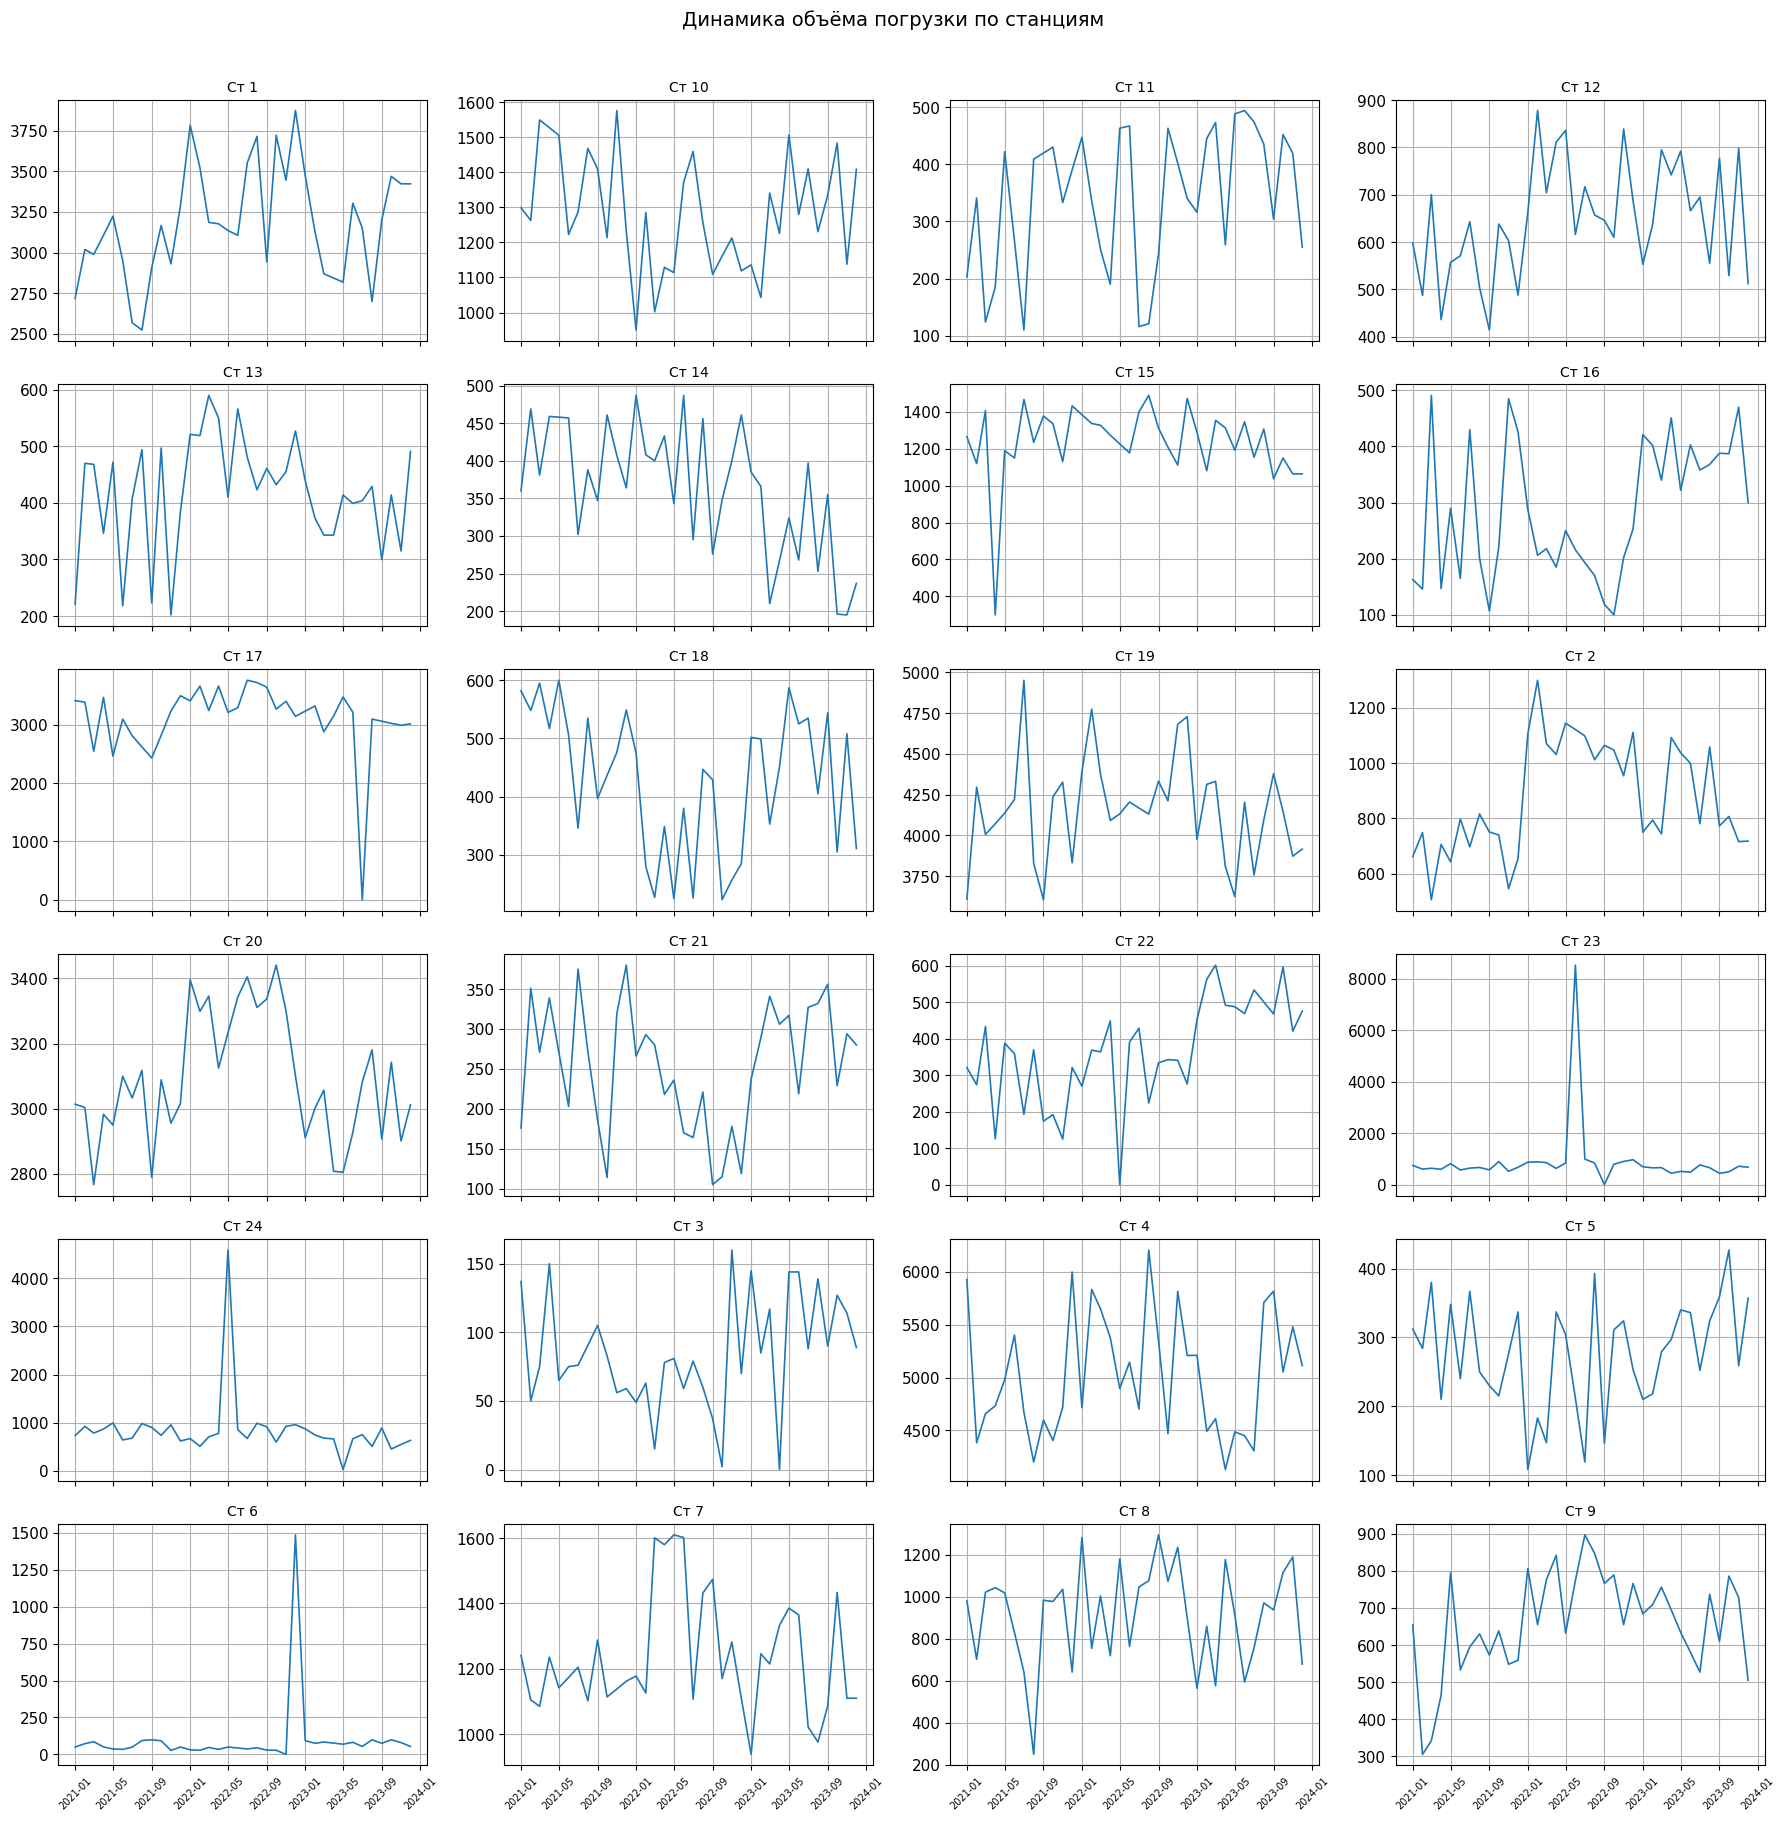

In [118]:
n_cols = 4
n_rows = int(np.ceil(len(stations) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
axes = axes.flatten()
for idx, st in enumerate(stations):
    axes[idx].plot(pivot.index, pivot[st], linewidth=1.2)
    axes[idx].set_title(short_names[idx], fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=7)
for idx in range(len(stations), len(axes)):
    axes[idx].set_visible(False)
fig.suptitle('Динамика объёма погрузки по станциям', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#3.2 Общий объем и средний сезонные профиль

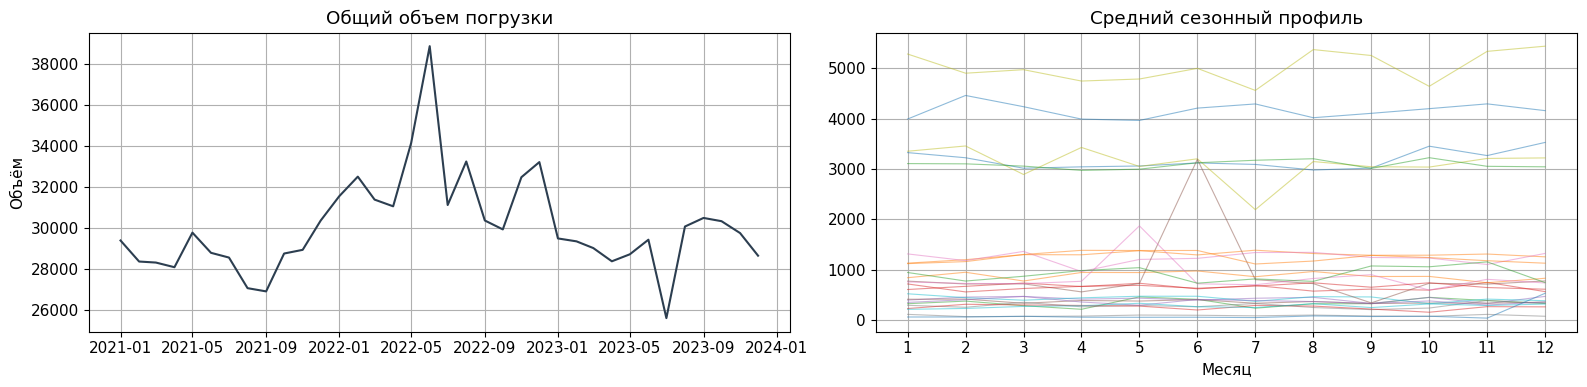

In [119]:
total = pivot.sum(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(total.index, total.values, color='#2c3e50', linewidth=1.5)
axes[0].set_title('Общий объем погрузки')
axes[0].set_ylabel('Объём')
monthly_avg = pivot.groupby(pivot.index.month).mean()
for st in stations:
    axes[1].plot(monthly_avg.index, monthly_avg[st], alpha=0.5, linewidth=0.8)
axes[1].set_title('Средний сезонный профиль')
axes[1].set_xlabel('Месяц')
axes[1].set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

#3.3 Описательная статистика

In [120]:
desc = pivot.describe().T
desc.columns = ['Всего наблюдений', 'Среднее', 'Ст.откл.', 'Мин', '25%', '50%', '75%', 'Макс']
desc.index = short_names
desc.round(1)

,Всего наблюдений,Среднее,Ст.откл.,Мин,25%,50%,75%,Макс
Ст 1,36.0,3176.6,337.2,2524.0,2939.2,3159.0,3428.5,3874.0
Ст 10,36.0,1285.3,162.4,950.0,1155.2,1271.5,1410.0,1577.0
Ст 11,36.0,341.3,120.9,110.0,254.0,365.5,445.5,494.0
Ст 12,36.0,648.7,119.6,414.0,556.5,644.5,723.2,878.0
Ст 13,36.0,416.7,99.1,202.0,366.2,426.0,483.5,590.0
Ст 14,36.0,363.9,85.4,195.0,300.2,373.5,438.8,487.0
Ст 15,36.0,1234.7,203.7,300.0,1149.0,1268.5,1347.0,1488.0
Ст 16,36.0,285.6,119.2,100.0,191.0,270.5,391.5,491.0
Ст 17,36.0,3102.5,632.5,0.0,3009.8,3225.2,3411.0,3763.0
Ст 18,36.0,428.2,120.1,223.0,337.2,449.0,527.5,600.0


#3.4 Боксплот

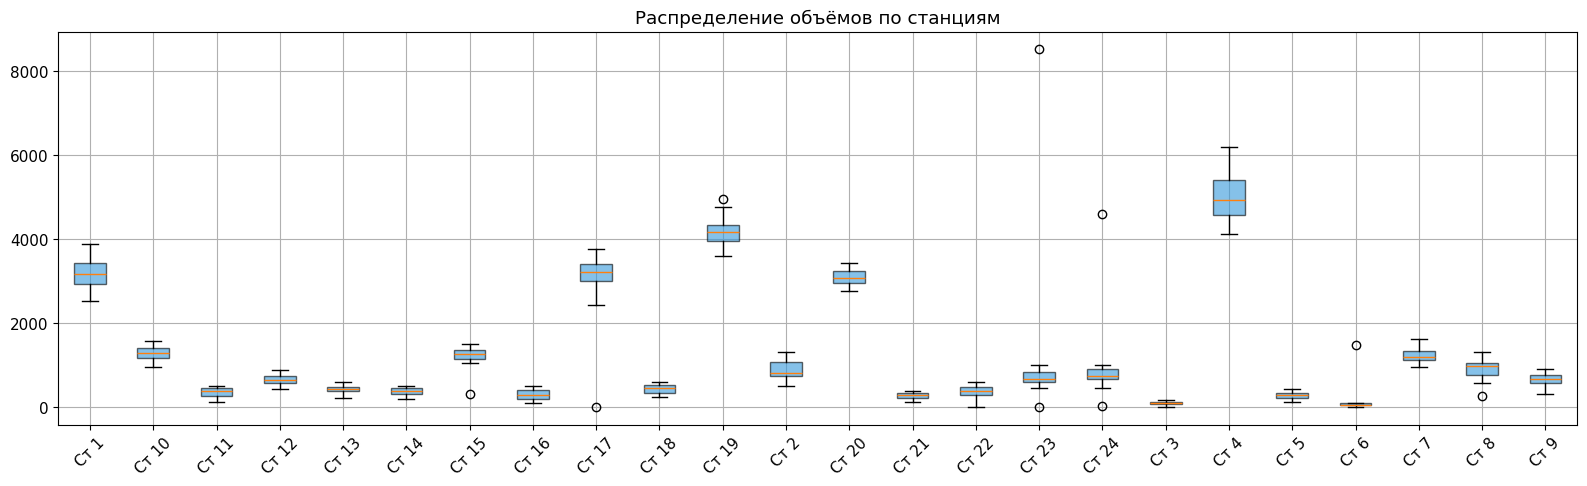

In [121]:
fig, ax = plt.subplots(figsize=(16, 5))
bp = ax.boxplot([pivot[st].dropna().values for st in stations], labels=short_names, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db'); patch.set_alpha(0.6)
ax.set_title('Распределение объёмов по станциям')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#3.4 Тепловая карта корреляций

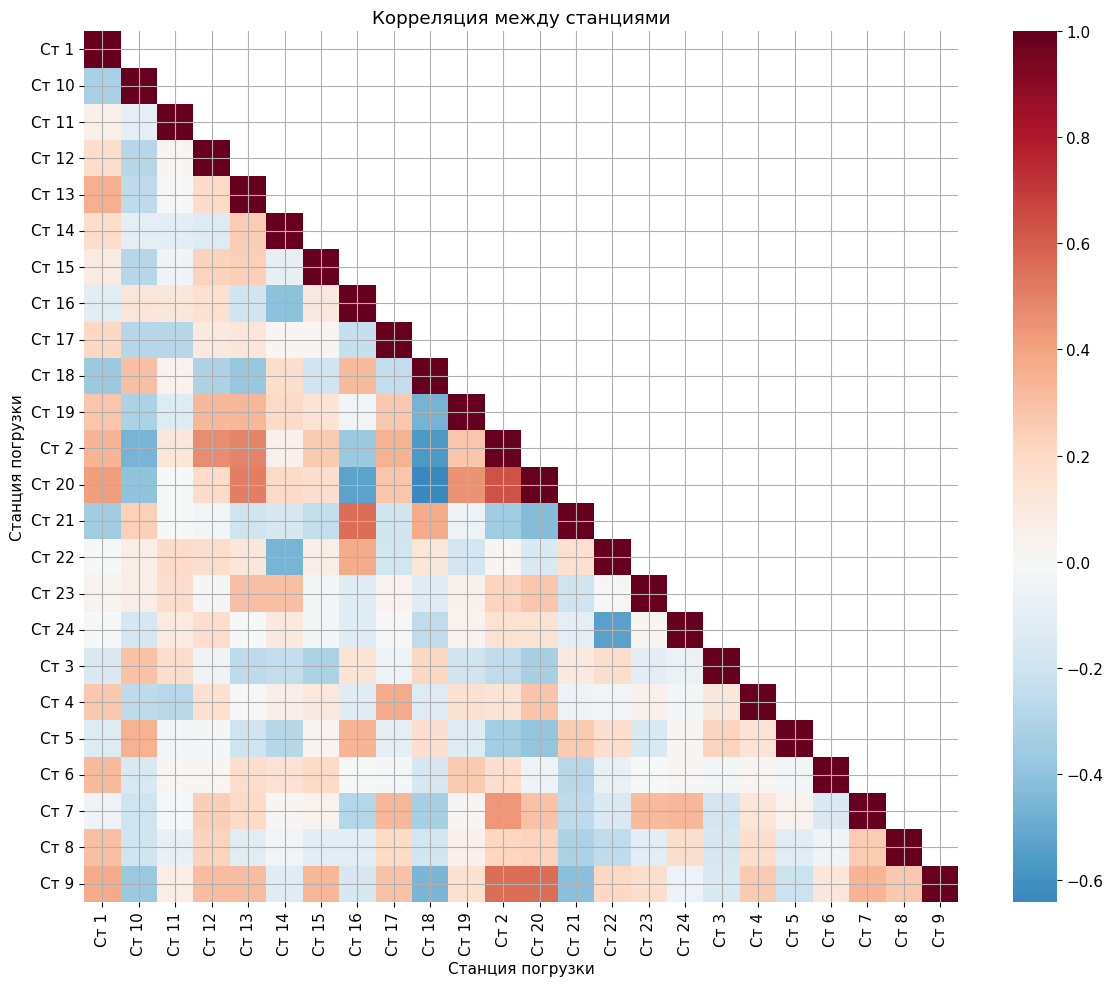

In [122]:
corr = pivot.corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_title('Корреляция между станциями')
plt.tight_layout()
plt.show()

#3.6 Декомпозиция

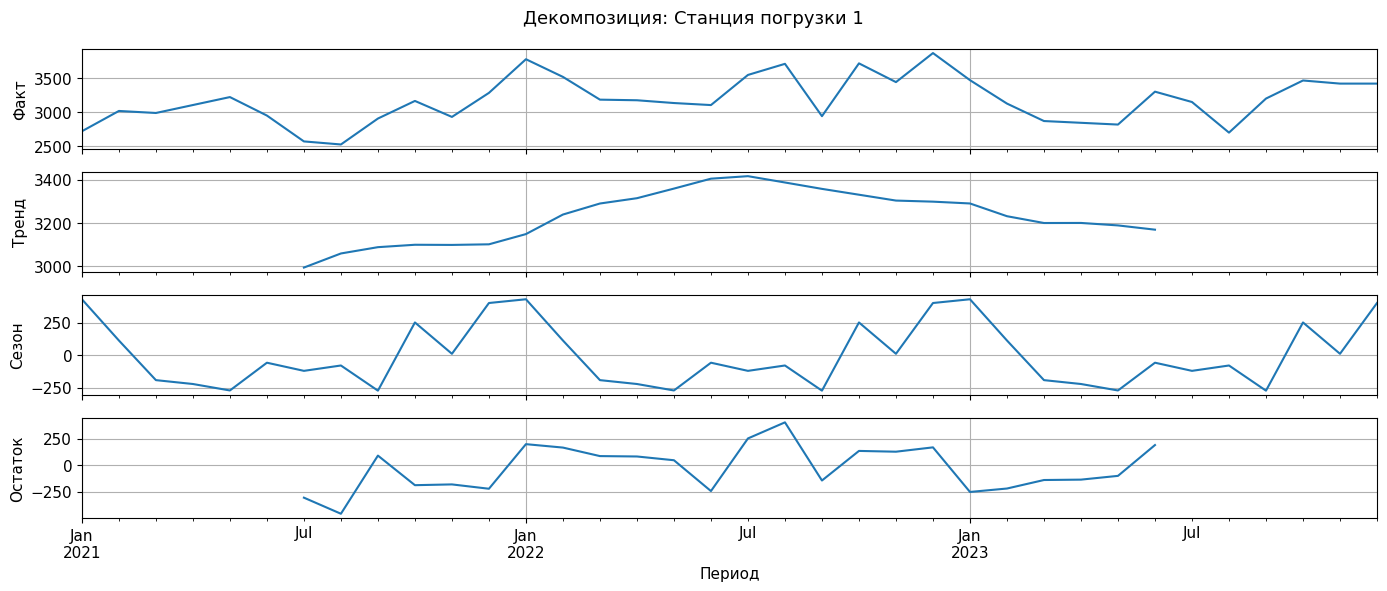

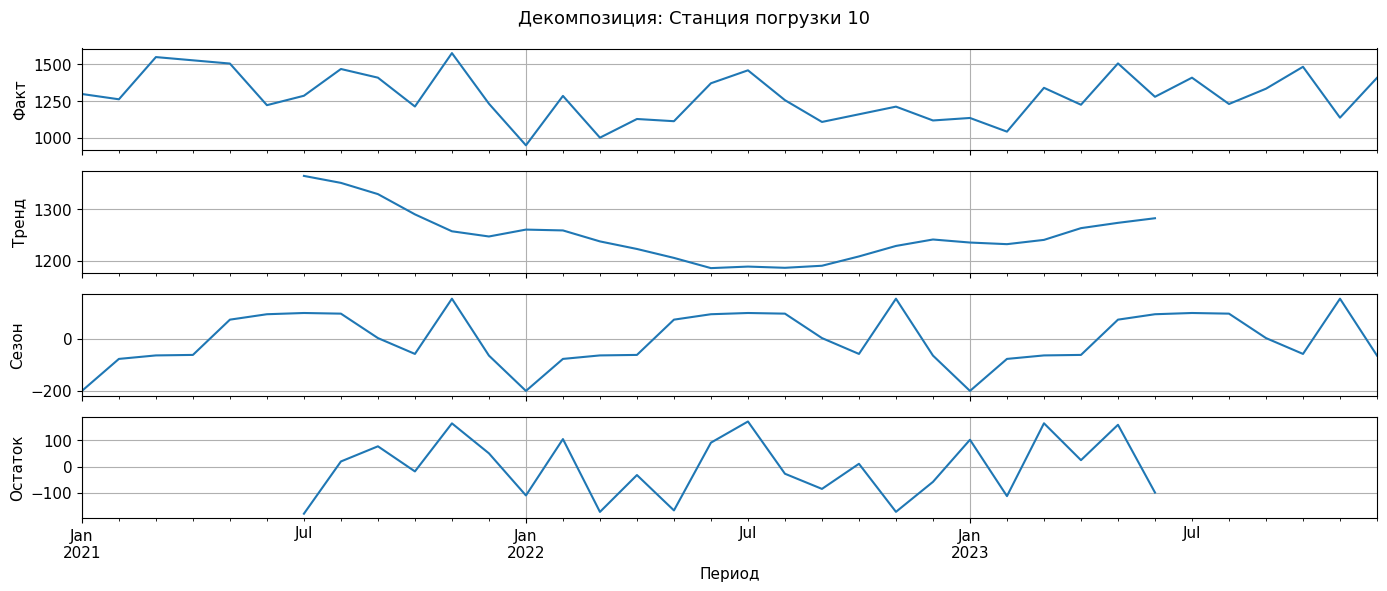

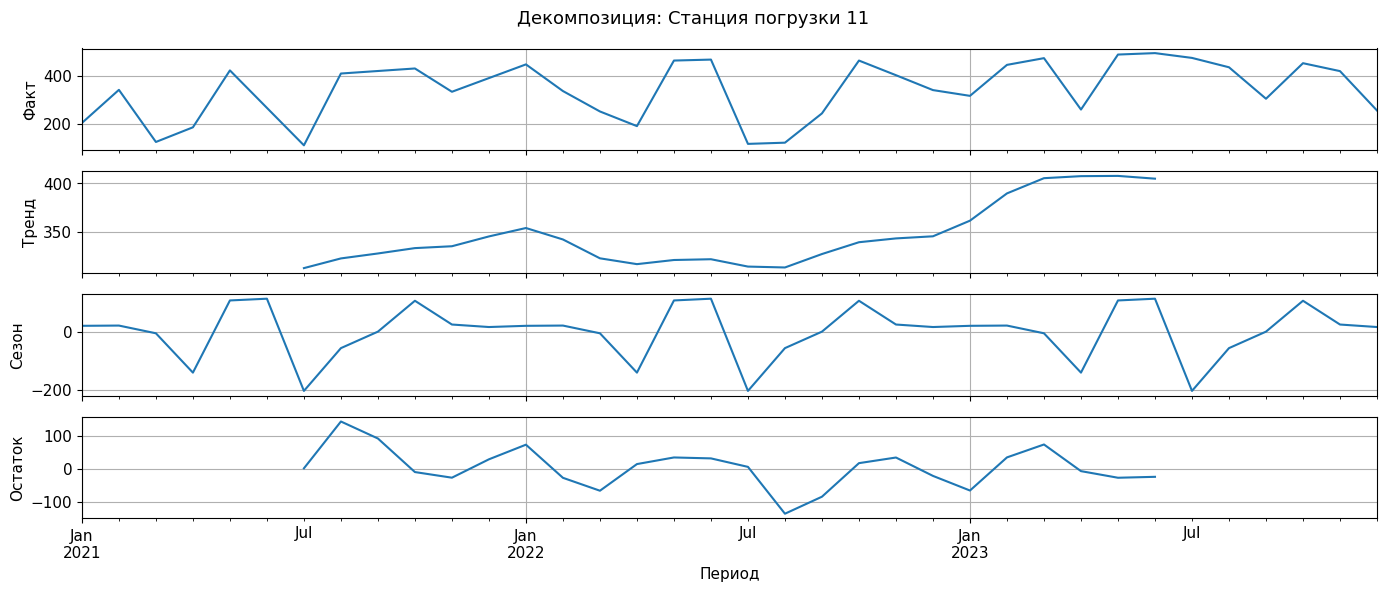

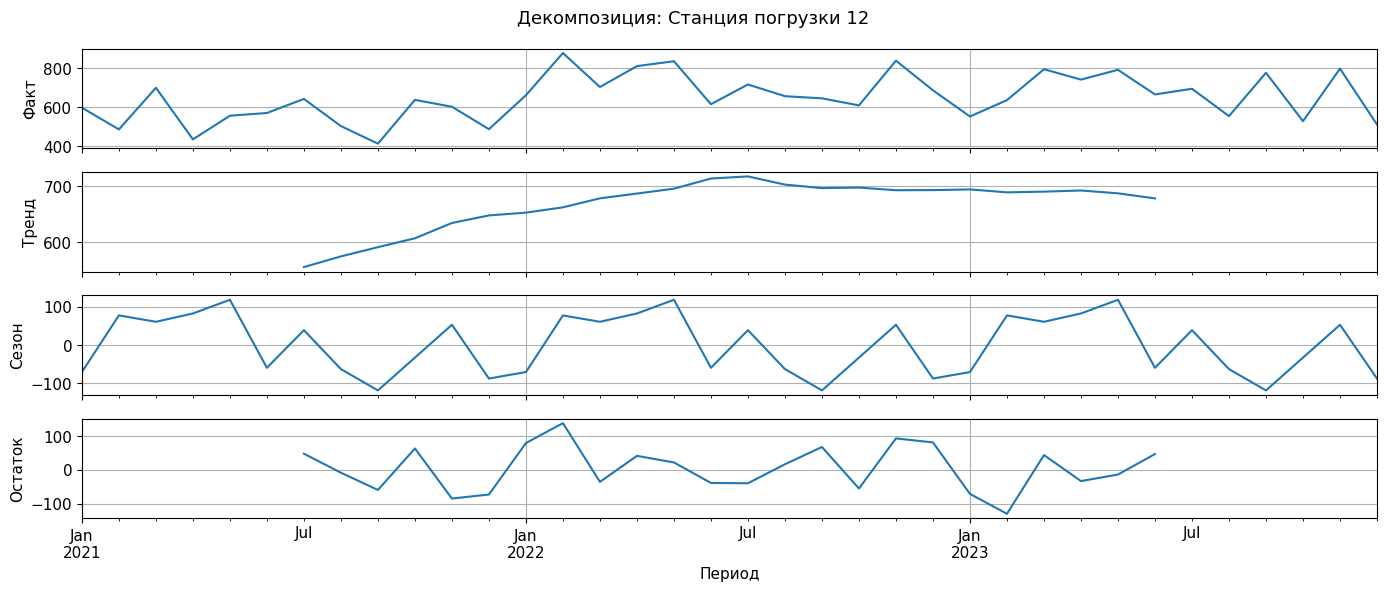

In [123]:
#на примере нескольких станции (в текущем варианте первых 4-х станций)
for st in stations[:4]:
    ts = pivot[st].copy()
    ts.index = pd.DatetimeIndex(ts.index, freq='MS')
    decomp = seasonal_decompose(ts, model='additive', period=12)
    fig, axes = plt.subplots(4, 1, figsize=(14, 6), sharex=True)
    decomp.observed.plot(ax=axes[0]); axes[0].set_ylabel('Факт')
    decomp.trend.plot(ax=axes[1]);    axes[1].set_ylabel('Тренд')
    decomp.seasonal.plot(ax=axes[2]); axes[2].set_ylabel('Сезон')
    decomp.resid.plot(ax=axes[3]);    axes[3].set_ylabel('Остаток')
    fig.suptitle(f'Декомпозиция: {st}', fontsize=13)
    plt.tight_layout()
    plt.show()

#3.7 Анализ пропусков

In [124]:
miss = pivot_raw.isna()
miss_counts = miss.sum()
print(f'Всего пропусков: {miss_counts.sum()} из {pivot_raw.size}')

Всего пропусков: 37 из 864


In [125]:
for st in stations:
    cnt = miss_counts[st]
    if cnt > 0:
        dates = pivot_raw.index[miss[st]].strftime('%Y-%m').tolist()
        print(f'  {st}: {cnt} ({", ".join(dates)})')

  Станция погрузки 1: 3 (2021-04, 2023-04, 2023-12)
  Станция погрузки 10: 2 (2021-04, 2022-10)
  Станция погрузки 11: 3 (2021-06, 2021-09, 2021-12)
  Станция погрузки 14: 2 (2021-05, 2023-04)
  Станция погрузки 15: 3 (2022-01, 2022-05, 2023-12)
  Станция погрузки 16: 1 (2022-07)
  Станция погрузки 17: 3 (2021-08, 2023-01, 2023-10)
  Станция погрузки 18: 1 (2021-10)
  Станция погрузки 19: 2 (2021-04, 2022-07)
  Станция погрузки 2: 1 (2022-06)
  Станция погрузки 21: 2 (2021-05, 2023-02)
  Станция погрузки 22: 1 (2023-08)
  Станция погрузки 3: 1 (2021-08)
  Станция погрузки 5: 2 (2021-11, 2022-06)
  Станция погрузки 6: 2 (2022-06, 2023-04)
  Станция погрузки 7: 4 (2021-06, 2021-11, 2022-12, 2023-12)
  Станция погрузки 8: 2 (2021-06, 2022-12)
  Станция погрузки 9: 2 (2023-04, 2023-06)


#3.8 Выводы по eda для каждой станции

In [126]:
month_names_ru = {
    1: 'янв', 2: 'фев', 3: 'мар', 4: 'апр', 5: 'май', 6: 'июн',
    7: 'июл', 8: 'авг', 9: 'сен', 10: 'окт', 11: 'ноя', 12: 'дек'
}

In [127]:
results = []

for st in stations:
    ts = pivot[st]
    mean_vol = ts.mean()
    std_vol = ts.std()
    cv = (std_vol / mean_vol * 100) if mean_vol > 0 else np.nan
    n_missing = int(pivot_raw[st].isna().sum())

    ts_idx = ts.copy()
    ts_idx.index = pd.DatetimeIndex(ts_idx.index, freq='MS')
    try:
        decomp = seasonal_decompose(ts_idx, model='additive', period=12)
        seasonal_amp = decomp.seasonal.max() - decomp.seasonal.min()
        tv = decomp.trend.dropna()
        trend_dir = 'растущий' if tv.iloc[-1] > tv.iloc[0] else 'убывающий'
    except Exception:
        seasonal_amp = np.nan
        trend_dir = 'не определён'

    peak = ts.groupby(ts.index.month).mean().idxmax()
    low = ts.groupby(ts.index.month).mean().idxmin()
    stability = (
        'стабильная' if cv < 30 else
        ('умеренно изменчивая' if cv < 60 else 'сильно изменчивая')
    )
    seas_str = (
        'выраженная' if seasonal_amp > mean_vol * 0.3 else
        ('умеренная' if seasonal_amp > mean_vol * 0.1 else 'слабая')
    )

    results.append({
        'Станция': st,
        'Средний объём': round(mean_vol, ndigits=None),
        'CV (%)': round(cv, ndigits=None),
        'Тренд': trend_dir,
        'Сезонность': seas_str,
        'Пик (мес.)': month_names_ru[peak],
        'Минимум (мес.)': month_names_ru[low],
        'Пропуски': n_missing,
        'Характер': stability
    })

df_results = pd.DataFrame(results)
df_results

,Станция,Средний объём,CV (%),Тренд,Сезонность,Пик (мес.),Минимум (мес.),Пропуски,Характер
0,Станция погрузки 1,3177,11,растущий,умеренная,дек,авг,3,стабильная
1,Станция погрузки 10,1285,13,убывающий,умеренная,июл,янв,2,стабильная
2,Станция погрузки 11,341,35,растущий,выраженная,май,апр,3,умеренно изменчивая
3,Станция погрузки 12,649,18,растущий,выраженная,ноя,дек,0,стабильная
4,Станция погрузки 13,417,24,растущий,выраженная,дек,ноя,0,стабильная
5,Станция погрузки 14,364,23,убывающий,выраженная,фев,сен,2,стабильная
6,Станция погрузки 15,1235,16,растущий,умеренная,мар,апр,3,стабильная
7,Станция погрузки 16,286,42,растущий,выраженная,ноя,сен,1,умеренно изменчивая
8,Станция погрузки 17,3103,20,убывающий,умеренная,фев,июл,3,стабильная
9,Станция погрузки 18,428,28,убывающий,выраженная,янв,окт,1,стабильная


#4 Вспомогательные функции

In [128]:
def make_features_basic(dates):
    df = pd.DataFrame(index=dates)
    df['trend'] = np.arange(len(df))
    month = df.index.month
    df['sin_month'] = np.sin(2 * np.pi * month / 12)
    df['cos_month'] = np.cos(2 * np.pi * month / 12)
    df['sin_month2'] = np.sin(4 * np.pi * month / 12)
    df['cos_month2'] = np.cos(4 * np.pi * month / 12)
    return df

In [129]:
def make_features_date(dates):
    df = make_features_basic(dates)
    df['year'] = dates.year
    df['month_num'] = dates.month
    df['quarter'] = dates.quarter
    return df

In [130]:
def make_features_full(dates):
    return make_features_date(dates)

In [131]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [132]:
def wape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom != 0 else np.nan

In [133]:
def evaluate(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    yt, yp = y_true[mask], y_pred[mask]
    if len(yt) == 0:
        return {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan, 'WAPE': np.nan}
    return {
        'MAE': mean_absolute_error(yt, yp),
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'MAPE': mape(yt, yp),
        'WAPE': wape(yt, yp),
    }

In [134]:
def recursive_predict(model, feature_fn, dates, history, n_train, use_lag=False, use_roll=False):
    preds = []
    h = list(history)
    for step_idx, dt in enumerate(dates):
        x_row = feature_fn(pd.DatetimeIndex([dt]))
        x_row['trend'] = n_train + step_idx
        if use_lag:
            x_row['lag_6'] = h[-6]
        if use_roll:
            x_row['roll_mean_6'] = float(np.mean(h[-6:]))
        y_hat = max(float(model.predict(x_row)[0]), 0.0)
        preds.append(y_hat)
        h.append(y_hat)
    return np.array(preds, dtype=float)

In [135]:
SARIMA_CANDIDATES = [
    ((1,1,1),(1,1,0,12)), ((1,0,1),(1,1,0,12)),
    ((0,1,1),(0,1,1,12)), ((1,1,0),(1,1,0,12)),
    ((1,0,0),(1,0,0,12)),
]

In [136]:
def fit_best_sarima(ts, candidates=SARIMA_CANDIDATES):
    best_fit, best_aic = None, np.inf
    for order, seasonal_order in candidates:
        try:
            m = SARIMAX(ts, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
            res = m.fit(disp=False, maxiter=300)
            if np.isfinite(res.aic) and res.aic < best_aic:
                best_aic = res.aic
                best_fit = res
        except Exception:
            continue
    return best_fit

#5. Обоснование выбора моделей

Для прогнозирования выбраны **10 моделей** (обучаются отдельно для каждой станции):

| # | Модель | Тип | Описание |
|---|--------|-----|----------|
| 1 | **Seasonal Naive** | baseline | Значение того же месяца прошлого года |
| 2 | **Mean Seasonal** | baseline | Среднее по тому же месяцу за все годы, которые есть в истории |
| 3 | **SARIMA** | статистическая | SARIMA с подбором порядка по AIC |
| 4 | **Holt-Winters** | статистическая | Тройное экспоненциальное сглаживание |
| 5 | **LR Basic** | ML | Тренд + sin/cos сезонности |
| 6 | **LR DateFeat** | ML | Тренд + год, месяц, квартал |
| 7 | **LR Lag6** | ML | Тренд + лаг 6 мес. (рекурсивный прогноз) |
| 8 | **LR RollMean** | ML | Тренд + скольз. среднее 6 мес. (рекурсивный) |
| 9 | **LR Lag6+Roll** | ML | Тренд + лаг + скольз. среднее (рекурсивный) |
| 10 | **Ridge** | ML | Полный набор + L2-регуляризация + стандартизация признаков (StandardScaler) + подбор alpha |

Baseline-модели (1–2) задают нижнюю планку качества

**Валидация:** walk-forward с 2мя фолдами.

#6. Кросс-валидация

**Фолды:**

Фолд 1: обучение 01.2021-12.2022 (24 мес), тест 01.2023-06.2023 2023-06 (6 мес)

Фолд 2: обучение 01.2021-06.2023(30 мес), тест 07.2023-12.2023(6 мес)

Метрики: среднее MAE/ RMSE/ MAPE/ WAPE по двум фолдам для каждой станции

In [137]:
FORECAST_HORIZON = 6

FOLDS = [
    ('2022-12-01', '2023-01-01', '2023-06-01'),
    ('2023-06-01', '2023-07-01', '2023-12-01'),
]

fold_data = []
for train_end, test_start, test_end in FOLDS:
    train_f = pivot_raw.loc[:train_end].copy()
    test_f = pivot_raw.loc[test_start:test_end].copy()
    for st in stations:
        train_f[st] = train_f[st].interpolate(method='linear').ffill().bfill()
    fold_data.append((train_f, test_f))
    print(f'Fold: train {train_f.index.min().date()}–{train_f.index.max().date()} '
                f'({len(train_f)} мес.), test {test_f.index.min().date()}–{test_f.index.max().date()} '
                f'({len(test_f)} мес.)')

Fold: train 2021-01-01–2022-12-01 (24 мес.), test 2023-01-01–2023-06-01 (6 мес.)
Fold: train 2021-01-01–2023-06-01 (30 мес.), test 2023-07-01–2023-12-01 (6 мес.)


#6.1 Seasonal Naive (baseline)

In [138]:
snaive_folds = []
snaive_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    for st in stations:
        pred_vals = []
        for dt in test_f.index:
            same_month_last_year = dt - pd.DateOffset(years=1)
            if same_month_last_year in train_f.index:
                pred_vals.append(max(train_f.loc[same_month_last_year, st], 0))
            else:
                pred_vals.append(train_f[st].mean())
        pred = np.array(pred_vals, dtype=float)
        preds[st] = pd.Series(pred, index=test_f.index, name=st)
        metrics[st] = evaluate(test_f[st], pred)
    snaive_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        snaive_last = preds
snaive_avg = pd.concat(snaive_folds).groupby(level=0).mean()
print(snaive_avg.mean().round(2))

MAE     267.25
RMSE    371.87
MAPE    112.15
WAPE     42.39
dtype: float64


### 6.2 Mean Seasonal (baseline)

In [139]:
mseas_folds = []
mseas_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    month_means = train_f.groupby(train_f.index.month).mean()
    for st in stations:
        pred = np.array([max(month_means.loc[dt.month, st], 0) for dt in test_f.index], dtype=float)
        preds[st] = pd.Series(pred, index=test_f.index, name=st)
        metrics[st] = evaluate(test_f[st], pred)
    mseas_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        mseas_last = preds
mseas_avg = pd.concat(mseas_folds).groupby(level=0).mean()
print(mseas_avg.mean().round(2))

MAE     194.51
RMSE    267.16
MAPE     70.80
WAPE     29.29
dtype: float64


### 6.3 SARIMA

In [140]:
sarima_folds = []
sarima_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    for st in stations:
        ts = train_f[st].copy()
        ts.index = pd.DatetimeIndex(ts.index, freq='MS')
        fit = fit_best_sarima(ts)
        pred = fit.forecast(steps=FORECAST_HORIZON).clip(lower=0)
        pred.index = test_f.index
        preds[st] = pred
        metrics[st] = evaluate(test_f[st], pred)
    sarima_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        sarima_last = preds
sarima_avg = pd.concat(sarima_folds).groupby(level=0).mean()
print(sarima_avg.mean().round(2))

MAE     370.28
RMSE    473.01
MAPE    132.03
WAPE     60.88
dtype: float64


### 6.4 Holt-Winters

In [141]:
hw_folds = []
hw_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    for st in stations:
        ts = train_f[st].copy()
        ts.index = pd.DatetimeIndex(ts.index, freq='MS')
        try:
            m = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12)
            fit = m.fit(optimized=True, use_brute=True)
        except Exception:
            m = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12,
                                    initialization_method='estimated')
            fit = m.fit(optimized=True)
        pred = fit.forecast(steps=FORECAST_HORIZON).clip(lower=0)
        pred.index = test_f.index
        preds[st] = pred
        metrics[st] = evaluate(test_f[st], pred)
    hw_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        hw_last = preds
hw_avg = pd.concat(hw_folds).groupby(level=0).mean()
print(hw_avg.mean().round(2))

MAE     436.16
RMSE    506.93
MAPE    236.79
WAPE    184.25
dtype: float64


### 6.5 Базовая линейная регрессия

In [142]:
lr_basic_folds = []
lr_basic_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    X_tr = make_features_basic(train_f.index)
    X_te = make_features_basic(test_f.index)
    X_te['trend'] = np.arange(len(train_f), len(train_f) + len(test_f))
    for st in stations:
        m = LinearRegression().fit(X_tr, train_f[st])
        pred = np.clip(m.predict(X_te), 0, None)
        preds[st] = pd.Series(pred, index=test_f.index, name=st)
        metrics[st] = evaluate(test_f[st], pred)
    lr_basic_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        lr_basic_last = preds
lr_basic_avg = pd.concat(lr_basic_folds).groupby(level=0).mean()
print(lr_basic_avg.mean().round(2))

MAE     314.16
RMSE    360.30
MAPE     74.94
WAPE     46.14
dtype: float64


### 6.6 LR + DateFeat

In [143]:
lr_date_folds = []
lr_date_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    X_tr = make_features_date(train_f.index)
    X_te = make_features_date(test_f.index)
    X_te['trend'] = np.arange(len(train_f), len(train_f) + len(test_f))
    for st in stations:
        m = LinearRegression().fit(X_tr, train_f[st])
        pred = np.clip(m.predict(X_te), 0, None)
        preds[st] = pd.Series(pred, index=test_f.index, name=st)
        metrics[st] = evaluate(test_f[st], pred)
    lr_date_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        lr_date_last = preds
lr_date_avg = pd.concat(lr_date_folds).groupby(level=0).mean()
print(lr_date_avg.mean().round(2))

MAE     331.69
RMSE    379.21
MAPE     78.26
WAPE     46.58
dtype: float64


### 6.7 LR + Lag6 (рекурсивный прогноз)

In [144]:
lr_lag_folds = []
lr_lag_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    for st in stations:
        series = train_f[st].copy()
        df_feat = make_features_basic(train_f.index)
        df_feat['lag_6'] = series.shift(6)
        valid = df_feat.dropna().index
        m = LinearRegression().fit(df_feat.loc[valid], series.loc[valid])
        pred = recursive_predict(m, make_features_basic, test_f.index,
                                 series.values, len(train_f), use_lag=True)
        preds[st] = pd.Series(pred, index=test_f.index, name=st)
        metrics[st] = evaluate(test_f[st], pred)
    lr_lag_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        lr_lag_last = preds
lr_lag_avg = pd.concat(lr_lag_folds).groupby(level=0).mean()
print(lr_lag_avg.mean().round(2))

MAE     382.88
RMSE    483.36
MAPE    134.74
WAPE    101.16
dtype: float64


### 6.8 LR + RollMean (рекурсивный прогноз)

In [145]:
lr_roll_folds = []
lr_roll_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    for st in stations:
        series = train_f[st].copy()
        df_feat = make_features_basic(train_f.index)
        df_feat['roll_mean_6'] = series.rolling(6, min_periods=1).mean().shift(1)
        valid = df_feat.dropna().index
        m = LinearRegression().fit(df_feat.loc[valid], series.loc[valid])
        pred = recursive_predict(m, make_features_basic, test_f.index,
                                 series.values, len(train_f), use_roll=True)
        preds[st] = pd.Series(pred, index=test_f.index, name=st)
        metrics[st] = evaluate(test_f[st], pred)
    lr_roll_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        lr_roll_last = preds
lr_roll_avg = pd.concat(lr_roll_folds).groupby(level=0).mean()
print(lr_roll_avg.mean().round(2))

MAE     336.24
RMSE    378.50
MAPE     76.11
WAPE     47.28
dtype: float64


### 6.9 LR + Lag6 + RollMean (рекурсивный прогноз)

In [146]:
lr_lagroll_folds = []
lr_lagroll_last = {}
for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    for st in stations:
        series = train_f[st].copy()
        df_feat = make_features_basic(train_f.index)
        df_feat['lag_6'] = series.shift(6)
        df_feat['roll_mean_6'] = series.rolling(6, min_periods=1).mean().shift(1)
        valid = df_feat.dropna().index
        m = LinearRegression().fit(df_feat.loc[valid], series.loc[valid])
        pred = recursive_predict(m, make_features_basic, test_f.index,
                                 series.values, len(train_f), use_lag=True, use_roll=True)
        preds[st] = pd.Series(pred, index=test_f.index, name=st)
        metrics[st] = evaluate(test_f[st], pred)
    lr_lagroll_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        lr_lagroll_last = preds
lr_lagroll_avg = pd.concat(lr_lagroll_folds).groupby(level=0).mean()
print(lr_lagroll_avg.mean().round(2))

MAE     383.93
RMSE    466.92
MAPE     88.31
WAPE     54.92
dtype: float64


### 6.10 Ridge (StandardScaler + подбор alpha через GridSearchCV)

In [147]:
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_folds = []
ridge_last = {}
ridge_best_alphas = {}

for fold_idx, (train_f, test_f) in enumerate(fold_data):
    preds, metrics = {}, {}
    for st in stations:
        series = train_f[st].copy()
        df_feat = make_features_full(train_f.index)
        df_feat['lag_6'] = series.shift(6)
        df_feat['roll_mean_6'] = series.rolling(6, min_periods=1).mean().shift(1)
        valid = df_feat.dropna().index
        X_tr = df_feat.loc[valid]
        y_tr = series.loc[valid]

        pipe = make_pipeline(StandardScaler(), Ridge())
        tscv = TimeSeriesSplit(n_splits=min(2, len(X_tr) // FORECAST_HORIZON - 1) or 2)
        search = GridSearchCV(pipe, {'ridge__alpha': RIDGE_ALPHAS},
                              cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1)
        search.fit(X_tr, y_tr)
        best_model = search.best_estimator_
        ridge_best_alphas[(fold_idx, st)] = search.best_params_['ridge__alpha']

        pred = recursive_predict(best_model, make_features_full, test_f.index,
                                 series.values, len(train_f), use_lag=True, use_roll=True)
        preds[st] = pd.Series(pred, index=test_f.index, name=st)
        metrics[st] = evaluate(test_f[st], pred)
    ridge_folds.append(pd.DataFrame(metrics).T)
    if fold_idx == len(fold_data) - 1:
        ridge_last = preds

ridge_avg = pd.concat(ridge_folds).groupby(level=0).mean()
print(ridge_avg.mean().round(2))

alpha_summary = pd.Series({st: ridge_best_alphas.get((len(fold_data)-1, st), np.nan) for st in stations})
print(f'\nЛучшие alpha (последний фолд): {dict(zip(short_names, alpha_summary.values))}')

MAE     233.10
RMSE    274.70
MAPE     48.68
WAPE     30.57
dtype: float64

Лучшие alpha (последний фолд): {'Ст 1': np.float64(100.0), 'Ст 10': np.float64(100.0), 'Ст 11': np.float64(100.0), 'Ст 12': np.float64(100.0), 'Ст 13': np.float64(100.0), 'Ст 14': np.float64(100.0), 'Ст 15': np.float64(10.0), 'Ст 16': np.float64(100.0), 'Ст 17': np.float64(100.0), 'Ст 18': np.float64(100.0), 'Ст 19': np.float64(100.0), 'Ст 2': np.float64(100.0), 'Ст 20': np.float64(100.0), 'Ст 21': np.float64(100.0), 'Ст 22': np.float64(100.0), 'Ст 23': np.float64(100.0), 'Ст 24': np.float64(100.0), 'Ст 3': np.float64(100.0), 'Ст 4': np.float64(100.0), 'Ст 5': np.float64(100.0), 'Ст 6': np.float64(100.0), 'Ст 7': np.float64(100.0), 'Ст 8': np.float64(100.0), 'Ст 9': np.float64(100.0)}


# 7. Сравнение метрик качества

In [148]:
MODEL_NAMES = ['SeasonalNaive', 'MeanSeasonal', 'SARIMA', 'Holt-Winters',
               'LR_Basic', 'LR_DateFeat', 'LR_Lag6', 'LR_RollMean',
               'LR_Lag6_Roll', 'Ridge']
ALL_AVG = [snaive_avg, mseas_avg, sarima_avg, hw_avg,
           lr_basic_avg, lr_date_avg, lr_lag_avg, lr_roll_avg,
           lr_lagroll_avg, ridge_avg]
ALL_LAST_PREDS = [snaive_last, mseas_last, sarima_last, hw_last,
                  lr_basic_last, lr_date_last, lr_lag_last, lr_roll_last,
                  lr_lagroll_last, ridge_last]

summary = pd.DataFrame({n: m.mean() for n, m in zip(MODEL_NAMES, ALL_AVG)}).T.round(2)
summary

,MAE,RMSE,MAPE,WAPE
SeasonalNaive,267.25,371.87,112.15,42.39
MeanSeasonal,194.51,267.16,70.80,29.29
SARIMA,370.28,473.01,132.03,60.88
Holt-Winters,436.16,506.93,236.79,184.25
LR_Basic,314.16,360.30,74.94,46.14
LR_DateFeat,331.69,379.21,78.26,46.58
LR_Lag6,382.88,483.36,134.74,101.16
LR_RollMean,336.24,378.50,76.11,47.28
LR_Lag6_Roll,383.93,466.92,88.31,54.92
Ridge,233.10,274.70,48.68,30.57


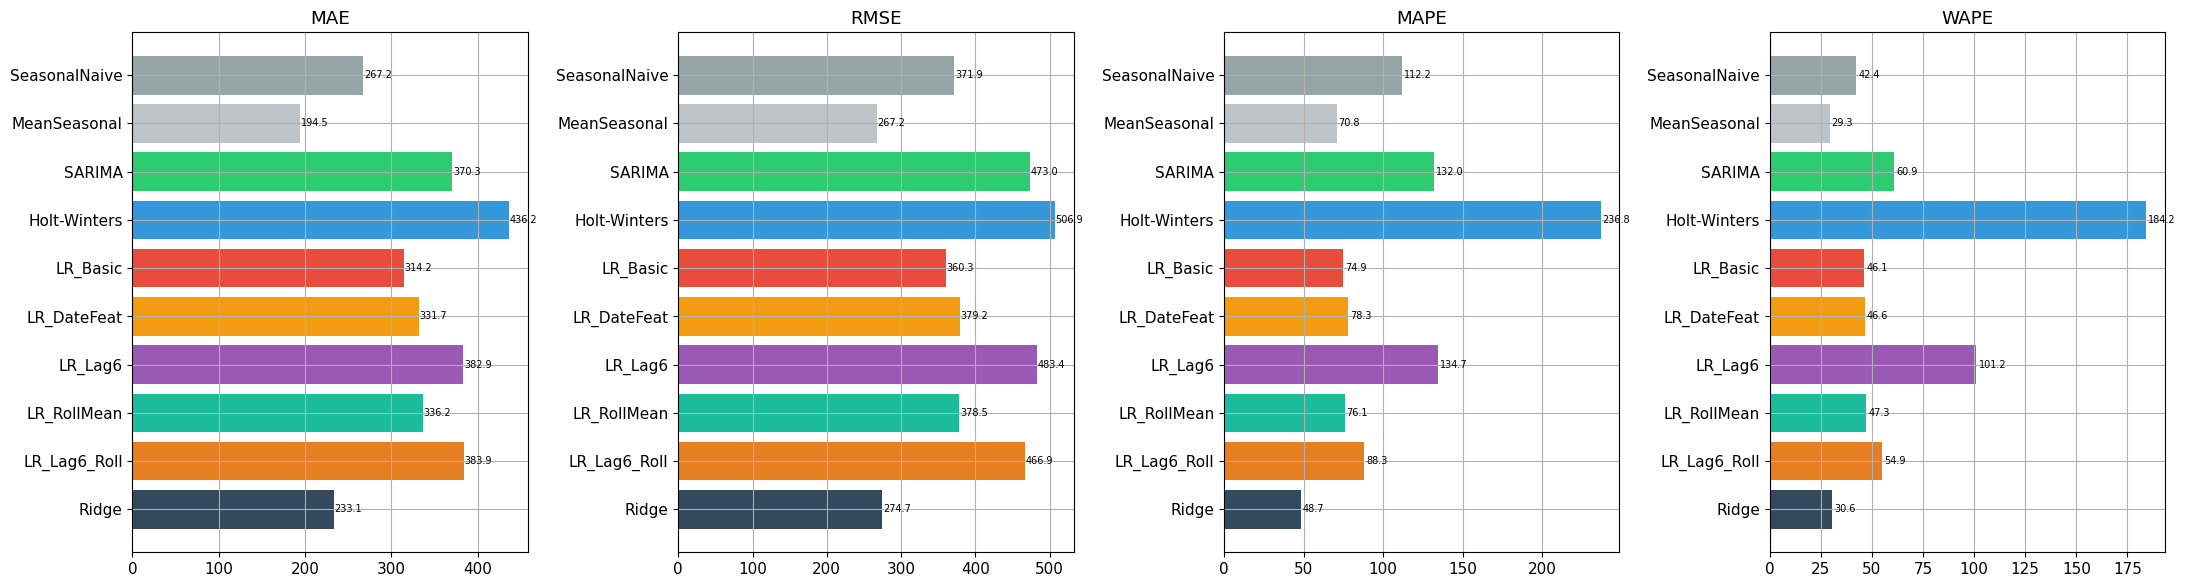

In [149]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metrics_list = ['MAE', 'RMSE', 'MAPE', 'WAPE']
colors = ['#95a5a6','#bdc3c7','#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e']
for i, metric in enumerate(metrics_list):
    vals = summary[metric]
    axes[i].barh(MODEL_NAMES, vals, color=colors[:len(MODEL_NAMES)])
    axes[i].set_title(metric)
    axes[i].invert_yaxis()
    for j, v in enumerate(vals):
        axes[i].text(v + 1, j, f'{v:.1f}', va='center', fontsize=7)
plt.tight_layout()
plt.show()

In [150]:
all_maes = pd.DataFrame({n: m['MAE'] for n, m in zip(MODEL_NAMES, ALL_AVG)})
all_maes.index = stations

best_model_per_station = {}
second_model_per_station = {}
wins = {m: 0 for m in MODEL_NAMES}

for st in stations:
    row = all_maes.loc[st].sort_values()
    best = row.index[0]
    second = row.index[1]
    best_model_per_station[st] = best
    second_model_per_station[st] = second
    wins[best] += 1

for st in stations:
    sn = st.replace('Станция погрузки ', 'Ст ')
    b, s = best_model_per_station[st], second_model_per_station[st]
    bv, sv = all_maes.loc[st, b], all_maes.loc[st, s]
    print(f'  {sn}: 1-е {b} (MAE={bv:.1f})  2-е {s} (MAE={sv:.1f})')

  Ст 1: 1-е MeanSeasonal (MAE=226.9)  2-е Ridge (MAE=269.9)
  Ст 10: 1-е Ridge (MAE=131.6)  2-е MeanSeasonal (MAE=138.0)
  Ст 11: 1-е Ridge (MAE=99.9)  2-е LR_Lag6_Roll (MAE=103.1)
  Ст 12: 1-е MeanSeasonal (MAE=86.4)  2-е Ridge (MAE=93.0)
  Ст 13: 1-е MeanSeasonal (MAE=60.5)  2-е Ridge (MAE=87.4)
  Ст 14: 1-е LR_RollMean (MAE=90.4)  2-е LR_Lag6_Roll (MAE=90.4)
  Ст 15: 1-е Ridge (MAE=114.1)  2-е SeasonalNaive (MAE=132.3)
  Ст 16: 1-е Ridge (MAE=149.1)  2-е MeanSeasonal (MAE=156.8)
  Ст 17: 1-е MeanSeasonal (MAE=531.7)  2-е Holt-Winters (MAE=602.7)
  Ст 18: 1-е MeanSeasonal (MAE=98.5)  2-е Ridge (MAE=137.0)
  Ст 19: 1-е Ridge (MAE=277.5)  2-е MeanSeasonal (MAE=298.0)
  Ст 2: 1-е MeanSeasonal (MAE=124.5)  2-е Ridge (MAE=198.9)
  Ст 20: 1-е MeanSeasonal (MAE=166.1)  2-е Ridge (MAE=256.6)
  Ст 21: 1-е MeanSeasonal (MAE=65.8)  2-е Ridge (MAE=85.9)
  Ст 22: 1-е LR_Lag6 (MAE=77.8)  2-е SARIMA (MAE=95.5)
  Ст 23: 1-е MeanSeasonal (MAE=469.1)  2-е Ridge (MAE=632.6)
  Ст 24: 1-е MeanSeasonal (M

# 8. Профили станций

In [151]:
profiles = []
for st in stations:
    ts = pivot[st]
    mean_vol = ts.mean()
    std_vol = ts.std()
    cv = std_vol / mean_vol * 100 if mean_vol > 0 else np.nan
    n_miss = int(pivot_raw[st].isna().sum())
    miss_pct = n_miss / len(pivot_raw) * 100

    ts_idx = ts.copy()
    ts_idx.index = pd.DatetimeIndex(ts_idx.index, freq='MS')
    try:
        decomp = seasonal_decompose(ts_idx, model='additive', period=12)
        seas_amp = decomp.seasonal.max() - decomp.seasonal.min()
        tv = decomp.trend.dropna()
        trend = 'растущий' if tv.iloc[-1] > tv.iloc[0] else 'убывающий'
    except Exception:
        seas_amp, trend = np.nan, '?'

    bm = best_model_per_station[st]
    bm2 = second_model_per_station[st]
    mae_best = all_maes.loc[st, bm]
    wape_best = ALL_AVG[MODEL_NAMES.index(bm)].loc[st, 'WAPE']

    profiles.append({
        'Станция': st.replace('Станция погрузки ', 'Ст '),
        'Ср.объём': round(mean_vol, 0),
        'CV%': round(cv, 1),
        'Тренд': trend,
        'Сезон.амп.': round(seas_amp, 0) if not np.isnan(seas_amp) else '?',
        'Пропуски%': round(miss_pct, 1),
        'Лучшая': bm,
        'MAE': round(mae_best, 1),
        'WAPE%': round(wape_best, 1),
        '2-я модель': bm2,
    })

profiles_df = pd.DataFrame(profiles)
profiles_df

,Станция,Ср.объём,CV%,Тренд,Сезон.амп.,Пропуски%,Лучшая,MAE,WAPE%,2-я модель
0,Ст 1,3177.0,10.6,растущий,707.0,8.3,MeanSeasonal,226.9,7.2,Ridge
1,Ст 10,1285.0,12.6,убывающий,357.0,5.6,Ridge,131.6,10.2,MeanSeasonal
2,Ст 11,341.0,35.4,растущий,318.0,8.3,Ridge,99.9,24.8,LR_Lag6_Roll
3,Ст 12,649.0,18.4,растущий,237.0,0.0,MeanSeasonal,86.4,12.9,Ridge
4,Ст 13,417.0,23.8,растущий,145.0,0.0,MeanSeasonal,60.5,15.6,Ridge
5,Ст 14,364.0,23.5,убывающий,168.0,5.6,LR_RollMean,90.4,31.1,LR_Lag6_Roll
6,Ст 15,1235.0,16.5,растущий,351.0,8.3,Ridge,114.1,9.7,SeasonalNaive
7,Ст 16,286.0,41.8,растущий,222.0,2.8,Ridge,149.1,38.7,MeanSeasonal
8,Ст 17,3103.0,20.4,убывающий,522.0,8.3,MeanSeasonal,531.7,20.6,Holt-Winters
9,Ст 18,428.0,28.0,убывающий,215.0,2.8,MeanSeasonal,98.5,21.8,Ridge


## 9. Прогноз на январь–июнь 2024

Переобучаем все 10 моделей на полных данных.
Для итогового прогноза используется модель с лучшим средним MAE для каждой станции.

In [152]:
forecast_dates = pd.date_range('2024-01-01', periods=FORECAST_HORIZON, freq='MS')
forecasts = {name: {} for name in MODEL_NAMES}

In [153]:
for st in stations:
    full_ts = pivot[st].copy()
    full_ts.index = pd.DatetimeIndex(full_ts.index, freq='MS')

    #Seasonal Naive
    forecasts['SeasonalNaive'][st] = np.array(
        [max(full_ts[full_ts.index.month == dt.month].iloc[-1], 0) for dt in forecast_dates])

    #Mean Seasonal
    month_avg = full_ts.groupby(full_ts.index.month).mean()
    forecasts['MeanSeasonal'][st] = np.array(
        [max(month_avg[dt.month], 0) for dt in forecast_dates])

    #SARIMA
    fit1 = fit_best_sarima(full_ts)
    forecasts['SARIMA'][st] = np.clip(fit1.forecast(steps=FORECAST_HORIZON).values, 0, None)

    #Holt-Winters
    try:
        m2 = ExponentialSmoothing(full_ts, trend='add', seasonal='add', seasonal_periods=12)
        f2 = m2.fit(optimized=True, use_brute=True)
    except Exception:
        m2 = ExponentialSmoothing(full_ts, trend='add', seasonal='add',
                                 seasonal_periods=12, initialization_method='estimated')
        f2 = m2.fit(optimized=True)
    forecasts['Holt-Winters'][st] = np.clip(f2.forecast(steps=FORECAST_HORIZON).values, 0, None)

    #LR Basic
    X_full_b = make_features_basic(pivot.index)
    X_fore_b = make_features_basic(forecast_dates)
    X_fore_b['trend'] = np.arange(len(pivot), len(pivot) + FORECAST_HORIZON)
    forecasts['LR_Basic'][st] = np.clip(LinearRegression().fit(X_full_b, pivot[st]).predict(X_fore_b), 0, None)

    #LR DateFeat
    X_full_d = make_features_date(pivot.index)
    X_fore_d = make_features_date(forecast_dates)
    X_fore_d['trend'] = np.arange(len(pivot), len(pivot) + FORECAST_HORIZON)
    forecasts['LR_DateFeat'][st] = np.clip(LinearRegression().fit(X_full_d, pivot[st]).predict(X_fore_d), 0, None)

    #LR Lag6 (recursive)
    df_l = make_features_basic(pivot.index); df_l['lag_6'] = full_ts.shift(6)
    vl = df_l.dropna().index
    m5 = LinearRegression().fit(df_l.loc[vl], pivot[st].loc[vl])
    forecasts['LR_Lag6'][st] = recursive_predict(m5, make_features_basic, forecast_dates,
                                                  full_ts.values, len(pivot), use_lag=True)

    #LR RollMean (recursive)
    df_r = make_features_basic(pivot.index)
    df_r['roll_mean_6'] = full_ts.rolling(6, min_periods=1).mean().shift(1)
    vr = df_r.dropna().index
    m6 = LinearRegression().fit(df_r.loc[vr], pivot[st].loc[vr])
    forecasts['LR_RollMean'][st] = recursive_predict(m6, make_features_basic, forecast_dates,
                                                      full_ts.values, len(pivot), use_roll=True)

    #LR Lag6+RollMean (recursive)
    df_lr = make_features_basic(pivot.index)
    df_lr['lag_6'] = full_ts.shift(6)
    df_lr['roll_mean_6'] = full_ts.rolling(6, min_periods=1).mean().shift(1)
    vlr = df_lr.dropna().index
    m7 = LinearRegression().fit(df_lr.loc[vlr], pivot[st].loc[vlr])
    forecasts['LR_Lag6_Roll'][st] = recursive_predict(m7, make_features_basic, forecast_dates,
                                                       full_ts.values, len(pivot), use_lag=True, use_roll=True)

    #Ridge (recursive + scaling + tuned alpha)
    df_ri = make_features_full(pivot.index)
    df_ri['lag_6'] = full_ts.shift(6)
    df_ri['roll_mean_6'] = full_ts.rolling(6, min_periods=1).mean().shift(1)
    vri = df_ri.dropna().index
    pipe8 = make_pipeline(StandardScaler(), Ridge())
    tscv8 = TimeSeriesSplit(n_splits=2)
    gs8 = GridSearchCV(pipe8, {'ridge__alpha': RIDGE_ALPHAS}, cv=tscv8, scoring='neg_mean_absolute_error')
    gs8.fit(df_ri.loc[vri], pivot[st].loc[vri])
    forecasts['Ridge'][st] = recursive_predict(gs8.best_estimator_, make_features_full, forecast_dates,
                                                full_ts.values, len(pivot), use_lag=True, use_roll=True)

print(f'Прогнозы построены для {len(MODEL_NAMES)} моделей × {len(stations)} станций.')

Прогнозы построены для 10 моделей × 24 станций.


In [154]:
best_forecast = pd.DataFrame(index=forecast_dates)
for st in stations:
    bm = best_model_per_station[st]
    best_forecast[st] = forecasts[bm][st]
best_forecast.index = best_forecast.index.strftime('%Y-%m')
best_forecast.round(0)

,Станция погрузки 1,Станция погрузки 10,Станция погрузки 11,Станция погрузки 12,Станция погрузки 13,Станция погрузки 14,Станция погрузки 15,Станция погрузки 16,Станция погрузки 17,Станция погрузки 18,...,Станция погрузки 22,Станция погрузки 23,Станция погрузки 24,Станция погрузки 3,Станция погрузки 4,Станция погрузки 5,Станция погрузки 6,Станция погрузки 7,Станция погрузки 8,Станция погрузки 9
2024-01,3325.0,1213.0,371.0,604.0,394.0,299.0,1200.0,351.0,3352.0,520.0,...,608.0,771.0,755.0,97.0,5284.0,210.0,111.0,1119.0,943.0,690.0
2024-02,3223.0,1214.0,367.0,667.0,454.0,271.0,1205.0,339.0,3457.0,442.0,...,686.0,714.0,724.0,96.0,4903.0,228.0,93.0,1159.0,773.0,710.0
2024-03,3015.0,1220.0,380.0,733.0,467.0,243.0,1187.0,331.0,2890.0,392.0,...,691.0,717.0,721.0,92.0,4973.0,269.0,77.0,1300.0,868.0,708.0
2024-04,3042.0,1241.0,379.0,663.0,413.0,234.0,1145.0,334.0,3428.0,439.0,...,639.0,557.0,768.0,96.0,4747.0,281.0,85.0,1383.0,981.0,707.0
2024-05,3059.0,1265.0,385.0,728.0,432.0,244.0,1146.0,339.0,3050.0,471.0,...,590.0,724.0,1869.0,99.0,4788.0,331.0,98.0,1379.0,1038.0,694.0
2024-06,3120.0,1274.0,389.0,618.0,394.0,253.0,1175.0,344.0,3202.0,470.0,...,597.0,3192.0,718.0,101.0,5000.0,262.0,109.0,1380.0,730.0,679.0


In [155]:
forecast_tables = {}
for name in MODEL_NAMES:
    df_fc = pd.DataFrame(index=forecast_dates)
    for st in stations:
        df_fc[st] = forecasts[name][st]
    df_fc.index = df_fc.index.strftime('%Y-%m')
    forecast_tables[name] = df_fc.round(0)

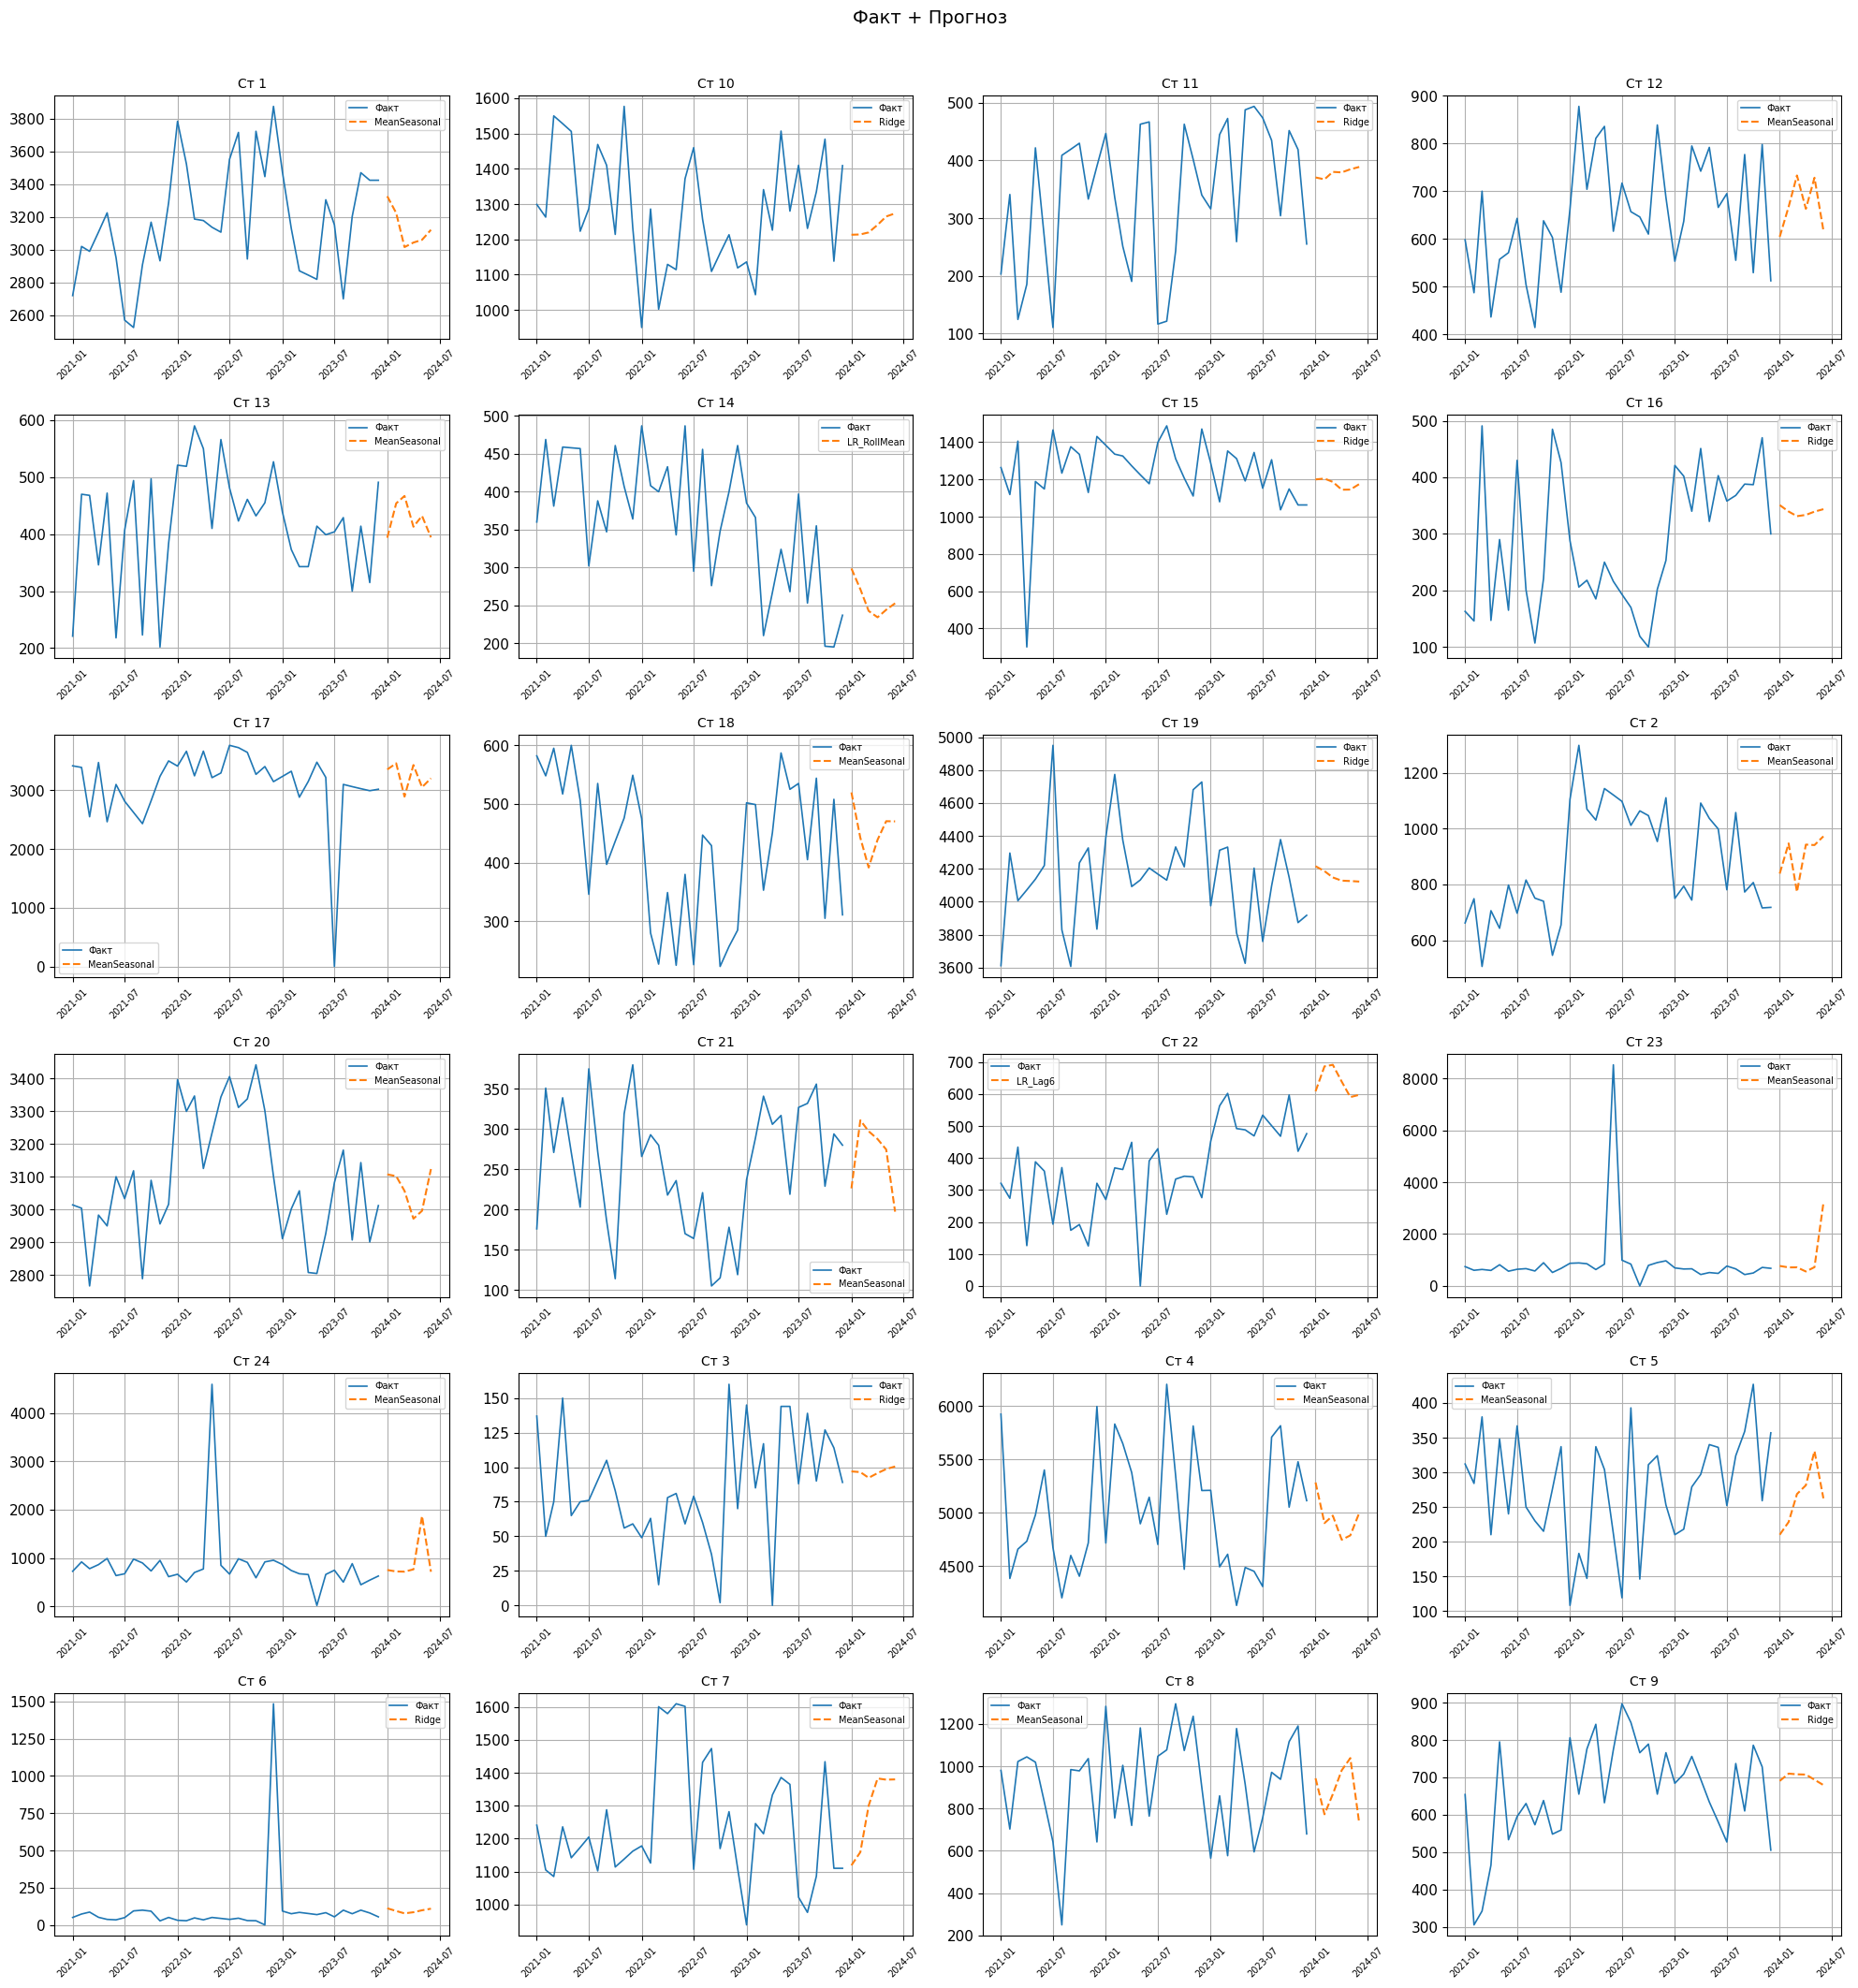

In [156]:
n_cols = 4
n_rows = int(np.ceil(len(stations) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
axes = axes.flatten()
fc_dates_plot = pd.date_range('2024-01-01', periods=FORECAST_HORIZON, freq='MS')
for idx, st in enumerate(stations):
    ax = axes[idx]
    ax.plot(pivot.index, pivot[st], label='Факт', linewidth=1.2)
    bm = best_model_per_station[st]
    ax.plot(fc_dates_plot, forecasts[bm][st], '--', label=f'{bm}', linewidth=1.5)
    ax.set_title(short_names[idx], fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
for idx in range(len(stations), len(axes)):
    axes[idx].set_visible(False)
fig.suptitle('Факт + Прогноз', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 10. Экспорт прогноза в Excel

In [157]:
output_file = 'Прогноз отгрузки_итоговый файл.xlsx'
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    best_fc_export = best_forecast.copy()
    best_fc_export.index.name = 'Период'
    best_fc_export.to_excel(writer, sheet_name='Лучший прогноз')

print(f'Файл {output_file} сформирован')

Файл Прогноз отгрузки_итоговый файл.xlsx сформирован


#Выводы

Всего было построено 3 класса подходов (10 моделей), а именно:
1. Базовая линия
2. Статистический подход
3. Регрессии

Также сформировала профили данных для общего понимания - можно ли спрогнозировать станции или нет. И для понимания почему разные модели лучше на разных станция

Я использовала конкретно эти модели потому что станции по характеру очень разные и отличаются по объему, cv, сезонности, тренду и наличием выбросов/пропусков

* SeasonalNaive, MeanSeasonal - хорошие baseline-модели

* SARIMA, Holt-Winters - используются когда ряд хорошо описывается классическими временными рядами

* LR Basic, LR DateFeat - используются когда важны тренд и календарные признаки

* LR_Lag6, LR_RollMean, LR_Lag6_Roll - в данных прогнозах помогает авторегрессия: прошлые значения и сглаженная история

* Ridge - используется когда признаки полезны, но ряд шумный или есть мультиколлинеарность, и нужна более устойчивая линейная модель.

В рамках тз я также учитывала короткий срок выполнения ТЗ и ограниченность данных, поэтому были использованы более простые и понятные модели.

То есть основная логика - не накидать как можно больше моделей, а постараться покрыть разные типы динамики.

#Если рассматривать причины выбора конкретной модели:

| **Станция** | **Модель** | **Комментарий** |
|:---:|:---|:---|
| **Ст 1** | MeanSeasonal | Ряд очень стабильный (CV 11%), сезонность сильная, тренд есть, но колебания небольшие. Простое среднее по месяцам оказалось лучше, чем более гибкие модели |
| **Ст 2** | MeanSeasonal | Умеренная вариативность, понятная сезонность, без сильного шума. Месячное среднее хорошо отражает форму ряда |
| **Ст 3** | Ridge | Очень маленький объём и высокая шумность (CV 48%). Ridge лучше сглаживает шум|
| **Ст 4** | MeanSeasonal | Большой стабильный ряд, выраженная сезонность, низкий CV. Простой сезонный шаблон работает лучше всего |
| **Ст 5** | MeanSeasonal | Умеренно стабильная станция, сложной динамики нет |
| **Ст 6** | Ridge | Очень шумная станция (CV 243%) с сильными выбросами. Ridge выигрывает за счёт регуляризации |
| **Ст 7** | MeanSeasonal | Низкая вариативность и хорошая повторяемость сезонного паттерна|
| **Ст 8** | MeanSeasonal | Хорошая повторяемость сезонного паттерна
| **Ст 9** | Ridge | Ряд умеренно стабильный, одной сезонности недостаточно. Ridge лучше сочетает тренд, календарь и сглаженную историю |
| **Ст 10** | Ridge | Стабильный, но убывающий ряд. Ridge лучше учитывает сезонность и нисходящий тренд |
| **Ст 11** | Ridge | Заметная относительная волатильность и сильная сезонная амплитуда. Нужна модель гибче baseline, но устойчивее обычной линейной регрессии |
| **Ст 12** | MeanSeasonal | Низкий CV, нет пропусков, структура ровная. Сезонность хорошая |
| **Ст 13** | MeanSeasonal | Стабильный растущий ряд, но рост слабее сезонности|
| **Ст 14** | LR_RollMean | Важен недавний локальный уровень |
| **Ст 15** | Ridge | Стабильная станция, Ridge обошёл даже SeasonalNaive. Скорее всего из-за учета тренда, сезонности и сглаженной истории |
| **Ст 16** | Ridge | Волатильность выше средней (CV 42%), ряд не очень ровный. Ridge лучше переносит смесь сезонности и шума |
| **Ст 17** | MeanSeasonal | Большой объём, умеренная вариативность, убывающий тренд. Сезонное усреднение устойчивее сложных моделей |
| **Ст 18** | MeanSeasonal | Умеренная стабильность, понятная сезонность |
| **Ст 19** | Ridge | Очень большой и очень стабильный ряд (CV 8%), но убывающий. Seasonal average недостаточно: Ridge лучше учёл тренд |
| **Ст 20** | MeanSeasonal | Самая стабильная из крупных станций (CV 6%), без пропусков. Очень хорошо подходит такая история для сезонного среднего|
| **Ст 21** | MeanSeasonal | Небольшой объём, умеренная волатильность, повторяемый сезонный профиль. Простая модель хорошо работает на такой истории |
| **Ст 22** | LR_Lag6 | Текущее значение лучше объясняется недавней историей ряда|
| **Ст 23** | MeanSeasonal | Очень нестабильная станция с экстремальными выбросами (CV 148%). Сглаженный baseline лучше сложной модели|
| **Ст 24** | MeanSeasonal | Очень шумная станция (CV 80%). Сложные модели почти не выигрывают, seasonal mean даёт наиболее устойчивый прогноз |